# CS6580 - Sprint 1

## Team Grapefruit

*Weber State University*

In [27]:
# Imports and global definitions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
import seaborn as sns
import os

interim_path = "https://connorwtech.com/resources/downloads/interim/"
processed_path = "https://connorwtech.com/resources/downloads/processed/"

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


## Data Transformation 1 (Age / Race Combos)

In [29]:
# Load datasets

df_A = pd.read_csv(processed_path + 'df_A.csv')

In [30]:
# Combine female age groups by race

df_A["NHWA_FEMALE_2034_share_X1"] = (
    df_A["NHWA_FEMALE_2024_C"] + df_A["NHWA_FEMALE_2529_C"] + df_A["NHWA_FEMALE_3034_C"]
    ) / (
    df_A["TOT_FEMALE_2024_C"] + df_A["TOT_FEMALE_2529_C"] + df_A["TOT_FEMALE_3034_C"])

df_A["NHBA_FEMALE_2034_share_X1"] = (
    df_A["NHBA_FEMALE_2024_C"] + df_A["NHBA_FEMALE_2529_C"] + df_A["NHBA_FEMALE_3034_C"]
    ) / (
    df_A["TOT_FEMALE_2024_C"] + df_A["TOT_FEMALE_2529_C"] + df_A["TOT_FEMALE_3034_C"])

df_A["H_FEMALE_2034_share_X1"] = (
    df_A["H_FEMALE_2024_C"] + df_A["H_FEMALE_2529_C"] + df_A["H_FEMALE_3034_C"]
    ) / (
    df_A["TOT_FEMALE_2024_C"] + df_A["TOT_FEMALE_2529_C"] + df_A["TOT_FEMALE_3034_C"])

In [31]:
df_A["race_category"] = "Mixed"

df_A.loc[df_A["NHWA_FEMALE_2034_share_X1"] >= 0.6, "race_category"] = "White"
df_A.loc[df_A["NHBA_FEMALE_2034_share_X1"] >= 0.6, "race_category"] = "Black"
df_A.loc[df_A["H_FEMALE_2034_share_X1"] >= 0.6, "race_category"] = "Hispanic"

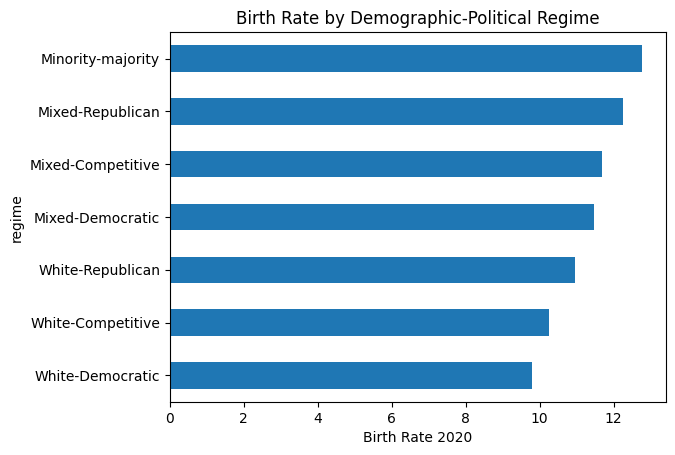

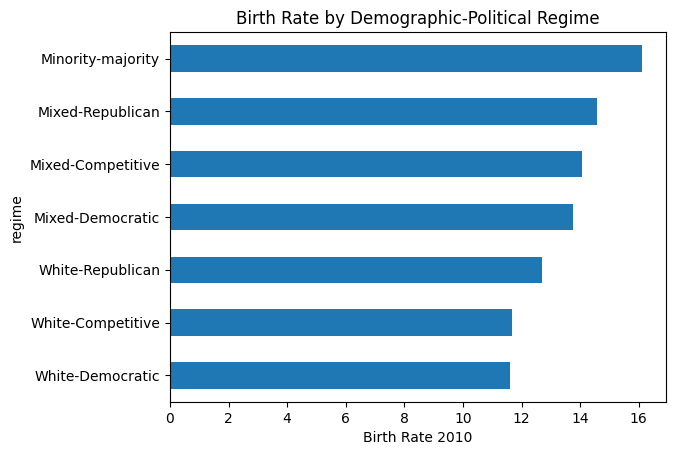

In [32]:
df_A["regime"] = "Minority-majority"

# White-majority
white_mask = df_A["NHWA_FEMALE_2034_share_X1"] >= 0.6

# Mixed
mixed_mask = df_A["race_category"] == "Mixed"

# Political classification
df_A["pol_group"] = "Competitive"
df_A.loc[df_A["dem2010_P"] <= 0.4, "pol_group"] = "Republican"
df_A.loc[df_A["dem2010_P"] >= 0.6, "pol_group"] = "Democratic"

# Assign regimes
df_A.loc[white_mask & (df_A["pol_group"] == "Republican"), "regime"] = "White-Republican"
df_A.loc[white_mask & (df_A["pol_group"] == "Democratic"), "regime"] = "White-Democratic"
df_A.loc[white_mask & (df_A["pol_group"] == "Competitive"), "regime"] = "White-Competitive"

df_A.loc[mixed_mask & (df_A["pol_group"] == "Republican"), "regime"] = "Mixed-Republican"
df_A.loc[mixed_mask & (df_A["pol_group"] == "Democratic"), "regime"] = "Mixed-Democratic"
df_A.loc[mixed_mask & (df_A["pol_group"] == "Competitive"), "regime"] = "Mixed-Competitive"

df_A["regime"].value_counts()
df_A.groupby("regime")["birth_rate_2020_N"].mean()

df_A["regime"].value_counts()

df_A.groupby("regime")["birth_rate_2020_N"].agg(["mean","std","count"])

means = df_A.groupby("regime")["birth_rate_2020_N"].mean().sort_values()
means.plot(kind="barh")
plt.xlabel("Birth Rate 2020")
plt.title("Birth Rate by Demographic-Political Regime")
plt.show()

means = df_A.groupby("regime")["birth_rate_2010_N"].mean().sort_values()
means.plot(kind="barh")
plt.xlabel("Birth Rate 2010")
plt.title("Birth Rate by Demographic-Political Regime")
plt.show()

In [33]:
df_A = df_A.loc[:, ~df_A.columns.str.startswith("reg_")]

regime_dummies = pd.get_dummies(df_A["regime"], prefix="reg")

# Attach to df_A
df_A = pd.concat([df_A, regime_dummies], axis=1)

# Verify
df_A.filter(like="reg_").head()

df_A.filter(like="reg_").sum(axis=1).value_counts()

,count
1,514


## Heat Map

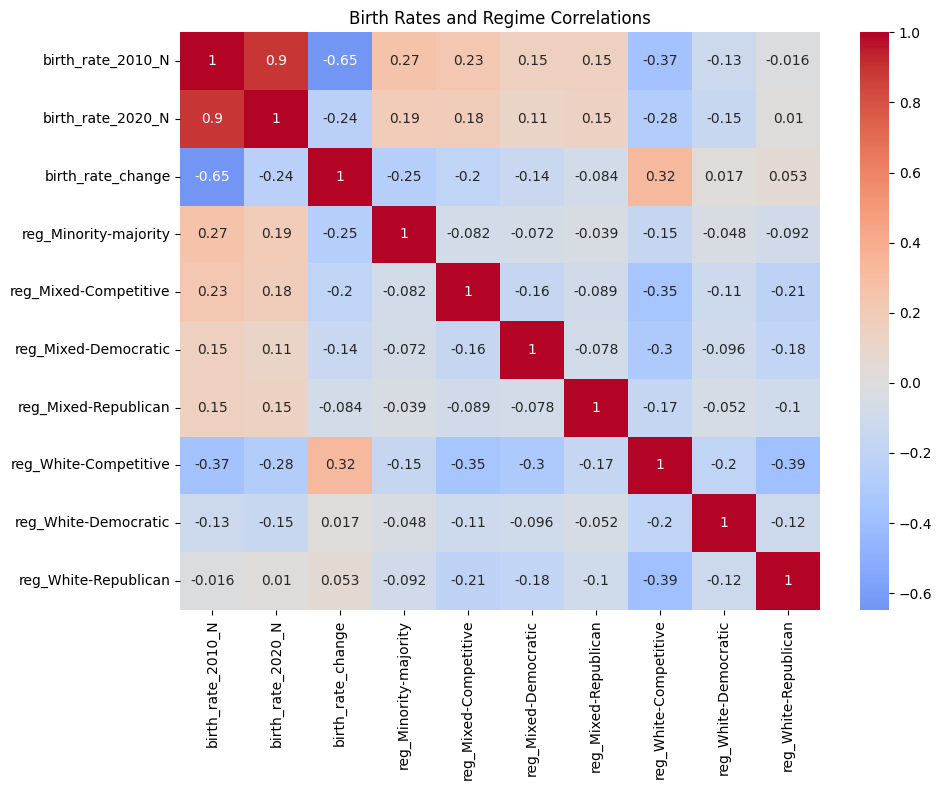

In [34]:
# Heat map

df_A["birth_rate_change"] = (
    df_A["birth_rate_2020_N"] - df_A["birth_rate_2010_N"]
)

df_A.groupby("regime")["birth_rate_change"].mean()

reg_cols = df_A.columns[df_A.columns.str.startswith("reg_")]
df_A[reg_cols] = df_A[reg_cols].astype(int)

df_A.loc[:, df_A.columns.str.startswith("reg_")] = \
    df_A.filter(like="reg_").astype(int)

cols = (
    ["birth_rate_2010_N", "birth_rate_2020_N"] +
    list(df_A.filter(like="reg_").columns)
)

cols = ["birth_rate_2010_N", "birth_rate_2020_N", "birth_rate_change"] + list(regime_dummies.columns)

corr_matrix = df_A[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Birth Rates and Regime Correlations")
plt.tight_layout()
plt.show()

In [35]:
regime_summary = (
    df_A
    .groupby("regime")[["birth_rate_2010_N", "birth_rate_2020_N"]]
    .mean()
)

regime_summary["pct_change"] = (
    (regime_summary["birth_rate_2020_N"] - regime_summary["birth_rate_2010_N"])
    / regime_summary["birth_rate_2010_N"]
) * 100

regime_summary = regime_summary.sort_values("birth_rate_2010_N", ascending=False)

regime_summary

,birth_rate_2010_N,birth_rate_2020_N,pct_change
regime,,,
Minority-majority,16.120556,12.773889,-20.760244
Mixed-Republican,14.571429,12.244762,-15.967320
Mixed-Competitive,14.069877,11.687654,-16.931365
Mixed-Democratic,13.754531,11.464688,-16.647923
White-Republican,12.700612,10.941735,-13.848762
White-Competitive,11.688657,10.254229,-12.271965
White-Democratic,11.590645,9.784194,-15.585428


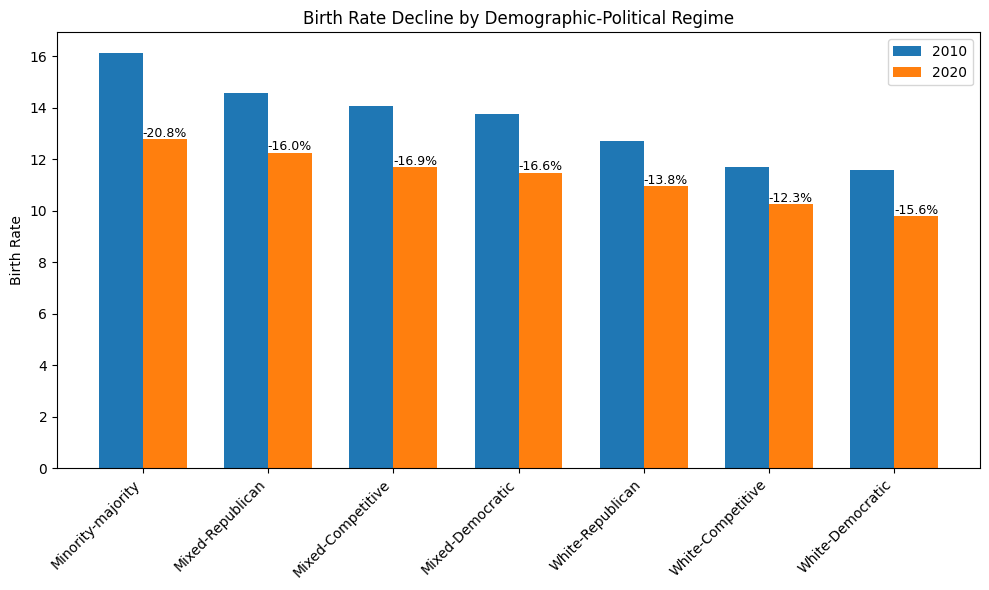

In [36]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(regime_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width/2,
               regime_summary["birth_rate_2010_N"],
               width,
               label="2010")

bars2 = ax.bar(x + width/2,
               regime_summary["birth_rate_2020_N"],
               width,
               label="2020")

ax.set_xticks(x)
ax.set_xticklabels(regime_summary.index, rotation=45, ha="right")
ax.set_ylabel("Birth Rate")
ax.set_title("Birth Rate Decline by Demographic-Political Regime")
ax.legend()

# Add % drop labels above 2020 bars
for i, v in enumerate(regime_summary["birth_rate_2020_N"]):
    pct = regime_summary["pct_change"].iloc[i]
    ax.text(i + width/2,
            v + 0.1,
            f"{pct:.1f}%",
            ha="center",
            fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
# Subset minority-majority counties
mm = df_A[df_A["reg_Minority-majority"] == 1].copy()

# Count by political group
mm_counts = mm["pol_group"].value_counts()

# Share by political group
mm_share = mm["pol_group"].value_counts(normalize=True)

# Average Democratic vote share
mm_avg_dem = mm["dem2010_P"].mean()

mm_counts, mm_share, mm_avg_dem

(pol_group
 Democratic     11
 Competitive     7
 Name: count, dtype: int64,
 pol_group
 Democratic     0.611111
 Competitive    0.388889
 Name: proportion, dtype: float64,
 np.float64(0.6258212850101238))

Minority-majority counties (n = 18) were predominantly Democratic-leaning, with 61% classified as Democratic and 39% as Competitive under the baseline 2008–2012 vote-share rule. The average Democratic vote share in these counties was 62.6%. No minority-majority counties were classified as Republican.

Due to the small subgroup counts and shared demographic structure, these counties were retained as a unified regime category to preserve statistical stability and avoid sparse cell bias.